## Inlab

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Scale pixel values to 0-1 range
X_train_cnn = X_train_raw.astype('float32') / 255.0
X_test_cnn = X_test_raw.astype('float32') / 255.0

# Add channel dimension (28x28x1) required by 2D Convolution layers
X_train_cnn = np.expand_dims(X_train_cnn, -1)
X_test_cnn = np.expand_dims(X_test_cnn, -1)

# One-hot encode classification targets
y_train_cnn = to_categorical(y_train_raw, 10)
y_test_cnn = to_categorical(y_test_raw, 10)

print("MNIST Image Dataset loaded successfully.")
print(f"  Training features shape: {X_train_cnn.shape} | Test features shape: {X_test_cnn.shape}")

MNIST Image Dataset loaded successfully.
  Training features shape: (60000, 28, 28, 1) | Test features shape: (10000, 28, 28, 1)


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Design sequential 2D CNN
cnn_model = Sequential([
    # Convolution layer 1: extracts 32 continuous spatial feature maps
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)), # Downsampling dimension reduction
    
    # Convolution layer 2: extracts 64 feature maps
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(), # Flatten 2D feature grids to 1D vector
    
    # Dense classification layers with Dropout regularization
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax') # Softmax activation for multi-class probability outputs
])

print("CNN Architecture successfully established:")
cnn_model.summary()


CNN Architecture successfully established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully with Adam optimizer.")

CNN model compiled successfully with Adam optimizer.


In [5]:
history_cnn = cnn_model.fit(
    X_train_cnn, 
    y_train_cnn, 
    epochs=5, 
    batch_size=64, 
    validation_split=0.1, 
    verbose=1
)

print("\nCNN training complete.")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9386 - loss: 0.2053 - val_accuracy: 0.9828 - val_loss: 0.0573
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.9789 - loss: 0.0689 - val_accuracy: 0.9880 - val_loss: 0.0408
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 22ms/step - accuracy: 0.9858 - loss: 0.0468 - val_accuracy: 0.9878 - val_loss: 0.0449
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9913 - val_loss: 0.0352
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.9904 - loss: 0.0304 - val_accuracy: 0.9897 - val_loss: 0.0352

CNN training complete.


CNN Holdout Test Accuracy: 99.11%

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
--- Classification Performance Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      1.00      1.00       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



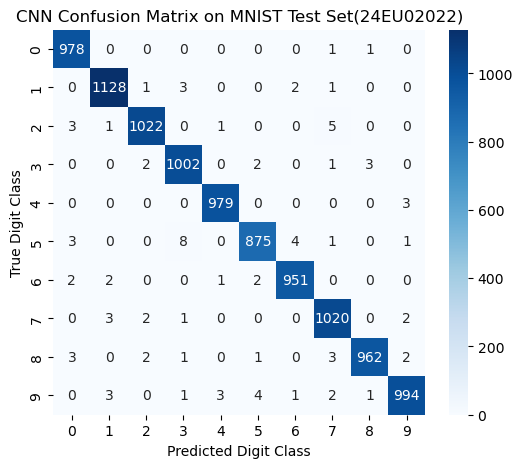

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

# Predict target classes
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("--- Classification Performance Report ---")
print(classification_report(y_test_raw, y_pred_classes))

# Plot confusion matrix
cm = confusion_matrix(y_test_raw, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("CNN Confusion Matrix on MNIST Test Set(24EU02022)")
plt.xlabel("Predicted Digit Class")
plt.ylabel("True Digit Class")
plt.show()

### Task-2

In [7]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic sine wave sequence
t_points = np.linspace(0, 100, 1000)
series_data = np.sin(t_points)

# Create sliding window function to format input-output sequence structures
def create_sliding_windows(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# Lookback window set to 20 steps
lookback_steps = 20
X_raw, y_raw = create_sliding_windows(series_data, lookback_steps)

# Reshape input X to fit 3D requirements: [samples, time_steps, features]
X_seq = np.expand_dims(X_raw, -1)
y_seq = y_raw

# Train-Test Split (80% train, 20% test)
split_idx = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print("Time Series Sequence Prepared:(24EU02022)")
print(f"  Training features shape: {X_train_seq.shape} | Test features shape: {X_test_seq.shape}")

Time Series Sequence Prepared:(24EU02022)
  Training features shape: (784, 20, 1) | Test features shape: (196, 20, 1)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Construct LSTM Network for sequence prediction
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1) # Linear continuous numeric output node
])

print("Sequential LSTM Architecture established:(24EU02022)")
lstm_model.summary()

Sequential LSTM Architecture established:(24EU02022)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM model
history_lstm = lstm_model.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

print("\nModel training complete.")

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.3996 - val_loss: 0.2209
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.1178 - val_loss: 0.0376
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0097 - val_loss: 0.0013
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0016 - val_loss: 9.0078e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.2489e-04 - val_loss: 6.9621e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 5.9284e-04 - val_loss: 5.3277e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 4.8558e-04 - val_loss: 4.4457e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.2777e-04 - val_loss: 4.2900e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 3.8459e-04 - val_loss: 3.0818e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 2.8984e-04 - val_loss: 2.8009e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 2.3937e-04 - val_loss: 1.9594e-04
Epo

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


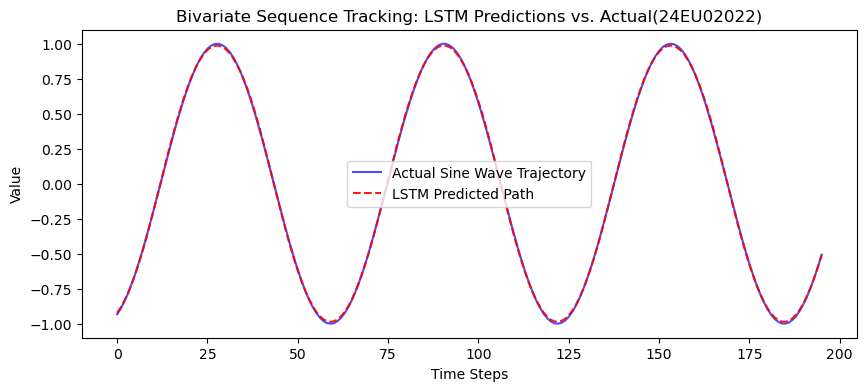

In [10]:
lstm_predictions = lstm_model.predict(X_test_seq)

# Plot actual trajectory vs predictions
plt.figure(figsize=(10, 4))
plt.plot(y_test_seq, label='Actual Sine Wave Trajectory', color='blue', alpha=0.7)
plt.plot(lstm_predictions, label='LSTM Predicted Path', color='red', linestyle='--', alpha=0.9)
plt.title("Bivariate Sequence Tracking: LSTM Predictions vs. Actual(24EU02022)")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute error metrics on predictions
mae_lstm = mean_absolute_error(y_test_seq, lstm_predictions)
mse_lstm = mean_squared_error(y_test_seq, lstm_predictions)
r2_lstm = r2_score(y_test_seq, lstm_predictions)

print("--- LSTM Quantitative Performance(24EU02022) ---")
print(f"Mean Absolute Error (MAE): {mae_lstm:.6f}")
print(f"Mean Squared Error (MSE):  {mse_lstm:.6f}")
print(f"Coefficient of Determination (R2): {r2_lstm:.6f}")

--- LSTM Quantitative Performance(24EU02022) ---
Mean Absolute Error (MAE): 0.006687
Mean Squared Error (MSE):  0.000060
Coefficient of Determination (R2): 0.999880


## Task 3

In [12]:
from tensorflow.keras.layers import SimpleRNN

# Construct SimpleRNN Model to act as a comparative baseline
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train SimpleRNN for 15 epochs
history_rnn = rnn_model.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=15, 
    batch_size=32, 
    validation_split=0.1, 
    verbose=1
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.1656 - val_loss: 0.0051
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0073 - val_loss: 0.0023
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0029 - val_loss: 0.0022
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0020 - val_loss: 0.0010
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 8.0934e-04 - val_loss: 7.7306e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 6.7974e-04 - val_loss: 5.2183e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.8972e-04 - val_loss: 5.4865e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.4394e-04 - val_loss: 3.2219e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3745e-04 - val_loss: 2.5942e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5277e-04 - val_loss: 2.8426e-04
Epoch 12/15
23/

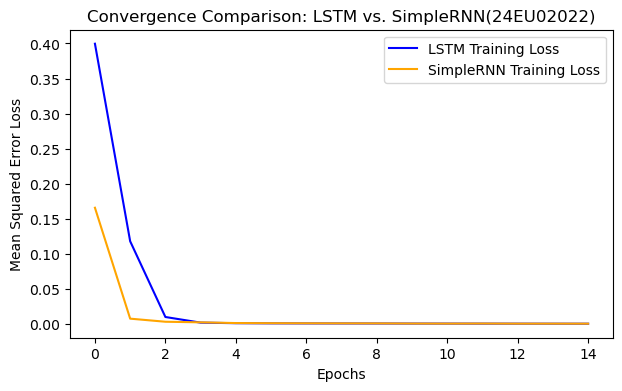

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss', color='blue')
plt.plot(history_rnn.history['loss'], label='SimpleRNN Training Loss', color='orange')
plt.title("Convergence Comparison: LSTM vs. SimpleRNN(24EU02022)")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.show()

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Implement dynamic learning rate reduction and early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Fit LSTM with optimization callbacks for robust convergence
tuned_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
tuned_lstm.compile(optimizer='adam', loss='mean_squared_error')

history_tuned = tuned_lstm.fit(
    X_train_seq, 
    y_train_seq, 
    epochs=30, 
    batch_size=32, 
    validation_split=0.1, 
    callbacks=[early_stop, reduce_lr], 
    verbose=1
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - loss: 0.2759 - val_loss: 0.1432 - learning_rate: 0.0010
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0618 - val_loss: 0.0030 - learning_rate: 0.0010
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0036 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9.8253e-04 - val_loss: 7.5908e-04 - learning_rate: 0.0010
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 4.9530e-04 - val_loss: 4.2272e-04 - learning_rate: 0.0010
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 4.0063e-04 - val_loss: 4.3009e-04 - learning_rate: 0.0010
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 3.2747e-04 - val_loss: 2.5661e-04 - learning_rate: 0.0010
Epoch 8/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 2.4523e-04 - val_loss: 1.8390e-04 - learning_rate: 0.0010
Epoch 9/30
18/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.8704e-04
Epoch 9: ReduceLRO

In [15]:
import pandas as pd

# Generate predictions across models
rnn_preds = rnn_model.predict(X_test_seq)
tuned_preds = tuned_lstm.predict(X_test_seq)

# Metrics calculation helper
def get_metrics(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), r2_score(y_true, y_pred)]

rnn_m = get_metrics(y_test_seq, rnn_preds)
lstm_m = get_metrics(y_test_seq, lstm_predictions)
tuned_m = get_metrics(y_test_seq, tuned_preds)

# Compile comparison DataFrame
comparison_table = pd.DataFrame(
    data=[rnn_m, lstm_m, tuned_m],
    columns=['MAE', 'MSE', 'R2_Score'],
    index=['Baseline SimpleRNN', 'Standard LSTM', 'Tuned/Optimized LSTM']
)
print("--- Quantitative Performance Comparison ---")
print(comparison_table.round(6))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
--- Quantitative Performance Comparison ---
                           MAE       MSE  R2_Score
Baseline SimpleRNN    0.009118  0.000139  0.999723
Standard LSTM         0.006687  0.000060  0.999880
Tuned/Optimized LSTM  0.007022  0.000061  0.999878


In [16]:
print("--- Deep Learning Performance Insights ---")
print("1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.")
print("2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.")
print("3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.")

--- Deep Learning Performance Insights ---
1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.
2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.
3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.
